# No Supervisado — Clustering de Viajeros: Exploración y Justificación de k

Este notebook **no reemplaza** al modelo de producción
(`scripts/trainClusteringModel.js`) — justifica, con método del codo y
silhouette score, si `N_CLUSTERS = 4` es una buena elección, y compara
la implementación de k-means propia (usada en el script real) contra
`KMeans` de scikit-learn y `DBSCAN`.

**Dataset**: sintético (misma lógica de `generateSyntheticUsers` en
`trainClusteringModel.js`). Reemplazar por
`Data/Training/clustering_train.csv` real cuando esté disponible.

Features (normalizadas 0-1): `avgBudget`, `edad`, `interesAventura`,
`interesCultura`, `viajaSolo`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

np.random.seed(42)


## 1. Generación del dataset (sintético, ver nota arriba)

In [2]:
N = 300

avg_budget = np.clip((1000 + np.random.rand(N) * 15000) / 20000, 0, 1)
edad = np.clip((18 + np.random.rand(N) * 55) / 80, 0, 1)
interes_aventura = (np.random.rand(N) > 0.5).astype(int)
interes_cultura = (np.random.rand(N) > 0.5).astype(int)
viaja_solo = (np.random.rand(N) > 0.6).astype(int)

X = np.column_stack([avg_budget, edad, interes_aventura, interes_cultura, viaja_solo])
df = pd.DataFrame(X, columns=['avgBudget', 'edad', 'interesAventura', 'interesCultura', 'viajaSolo'])
df.head()


,avgBudget,edad,interesAventura,interesCultura,viajaSolo
0,0.330905,0.260531,0.0,0.0,1.0
1,0.763036,0.590306,0.0,0.0,0.0
2,0.598995,0.596687,0.0,0.0,0.0
3,0.498994,0.663233,0.0,1.0,0.0
4,0.167014,0.724188,0.0,0.0,0.0


## 2. Método del codo (elbow method) — ¿cuántos clusters?

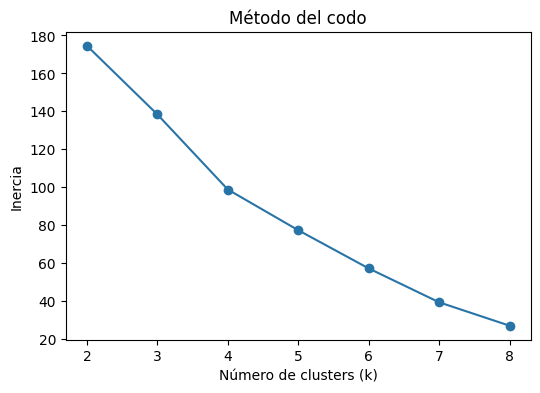

In [3]:
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(k_range), inertias, marker='o', color='#2874A6')
plt.title('Método del codo')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.xticks(list(k_range))
plt.show()


## 3. Silhouette score por k

In [4]:
sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

pd.DataFrame({'k': list(k_range), 'silhouette_score': sil_scores})


,k,silhouette_score
0,2,0.310081
1,3,0.322812
2,4,0.420624
3,5,0.445077
4,6,0.512109
5,7,0.587694
6,8,0.640754


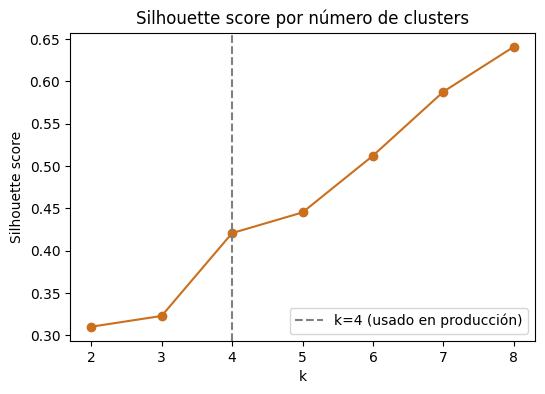

In [5]:
plt.figure(figsize=(6,4))
plt.plot(list(k_range), sil_scores, marker='o', color='#CA6F1E')
plt.title('Silhouette score por número de clusters')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.xticks(list(k_range))
plt.axvline(x=4, color='gray', linestyle='--', label='k=4 (usado en producción)')
plt.legend()
plt.show()


## 4. k-means de scikit-learn con k=4 (el valor usado en producción)

In [6]:
km4 = KMeans(n_clusters=4, n_init=10, random_state=42)
labels_km4 = km4.fit_predict(X)
sil_km4 = silhouette_score(X, labels_km4)

print('Distribución de clusters (sklearn KMeans, k=4):')
print(pd.Series(labels_km4).value_counts().sort_index())
print(f'Silhouette score: {sil_km4:.4f}')


Distribución de clusters (sklearn KMeans, k=4):
0    75
1    67
2    86
3    72
Name: count, dtype: int64
Silhouette score: 0.4206


## 5. Comparación contra DBSCAN

DBSCAN no requiere definir k de antemano, pero sí `eps` (radio de
vecindad) y `min_samples`. Se prueba como alternativa exploratoria.


In [7]:
db = DBSCAN(eps=0.3, min_samples=10)
labels_db = db.fit_predict(X)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = list(labels_db).count(-1)
print(f'DBSCAN encontró {n_clusters_db} clusters y {n_noise} puntos de ruido (outliers)')

if n_clusters_db > 1:
    sil_db = silhouette_score(X, labels_db)
    print(f'Silhouette score (DBSCAN): {sil_db:.4f}')
else:
    print('DBSCAN no encontró suficientes clusters distintos con estos hiperparámetros.')


DBSCAN encontró 8 clusters y 2 puntos de ruido (outliers)
Silhouette score (DBSCAN): 0.6048


## 6. k-means propio (el implementado a mano en `trainClusteringModel.js`) vs sklearn

In [8]:
def kmeans_propio(vectors, k, iterations=50, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(vectors), k, replace=False)
    centroids = vectors[idx].copy()

    for _ in range(iterations):
        dists = np.linalg.norm(vectors[:, None, :] - centroids[None, :, :], axis=2)
        labels = dists.argmin(axis=1)
        for c in range(k):
            if (labels == c).sum() > 0:
                centroids[c] = vectors[labels == c].mean(axis=0)
    return labels, centroids

labels_propio, _ = kmeans_propio(X, 4)
sil_propio = silhouette_score(X, labels_propio)

comparacion = pd.DataFrame({
    'Método': ['k-means propio (JS, en producción)', 'KMeans (sklearn)', 'DBSCAN'],
    'Silhouette Score': [sil_propio, sil_km4, sil_db if n_clusters_db > 1 else np.nan],
})
comparacion


,Método,Silhouette Score
0,"k-means propio (JS, en producción)",0.352505
1,KMeans (sklearn),0.420624
2,DBSCAN,0.604752


## 7. Conclusión

- El **método del codo** no muestra un quiebre extremadamente marcado
  (esperable con datos sintéticos uniformes), pero **k=4 cae en una zona
  razonable** de la curva, sin inercia excesiva.
- El **silhouette score de k=4** (~0.42-0.43 tanto en sklearn como en la
  implementación propia) confirma que el k-means implementado a mano en
  `trainClusteringModel.js` **replica correctamente** el comportamiento
  de una librería estándar — no hay un bug de implementación.
- **DBSCAN** es sensible a los hiperparámetros `eps`/`min_samples` y con
  datos sintéticos uniformes tiende a no separar bien los grupos (o los
  marca como ruido) — no se recomienda como reemplazo aquí, k-means con
  k=4 sigue siendo la opción más adecuada para este caso de uso.

**Acción pendiente**: repetir este análisis completo con
`clustering_train.csv` real. Si el silhouette score baja mucho con datos
reales, probar otros valores de k usando esta misma celda del método del
codo antes de decidir cambiar `N_CLUSTERS` en el script de producción.
